# Latihan Mandiri 1 Pemrograman Paralel
**Nama: Prima Azahra         
Nim: 2411511005**

### 1. Klasifikasi Flynn: Untuk masing-masing skenario berikut, tentukan kategori Flynn (SISD/SIMD/MISD/MIMD) beserta alasannya:  
**a) Operasi arr + arr pada NumPy array** termasuk kedalam SIMD (Single Instruction, Multiple Data), alasannya instruksi penjumlahan yang sama dieksekusi secara berbarengan (vectorized) pada banyak elemen data di dalam array.        
**b) Program Python biasa (tanpa threading/multiprocessing) membaca file baris demi baris** termasuk kedalam SISD (Single Instruction, Single Data), alasannya program berjalan secara sekuensial tunggal pada satu alur instruksi dan memproses satu data (baris) pada satu waktu.      
**c) Cluster komputer yang masing-masing node menjalankan simulasi cuaca independen** termasuk kedalam MIMD (Multiple Instruction, Multiple Data), alasannya setiap node komputer bekerja secara independen mengeksekusi instruksinya sendiri pada kumpulan data wilayahnya masing-masing.

### 2. Analisis Amdahl: Sebuah aplikasi pengolahan citra memiliki proporsi paralel $P = 0.85$.
**a) Hitung speedup teoritis untuk $N = 2, 4, 8, 16, 32, 64$ (gunakan fungsi amdahl_speedup di atas)**      
**b) Buat plot speedup vs $N$**        
**c) Pada $N$ berapa penambahan prosesor mulai memberikan manfaat yang sangat kecil ("diminishing returns")? Jelaskan alasan kalian**

In [1]:
# a) Hitung speedup teoritis
import matplotlib.pyplot as plt
import numpy as np
def amdahl_speedup(P, N):
  return 1 / ((1 - P) + P / N)

P = 0.85
N_values = np.array([2, 4, 8, 16, 32, 64])
speedups = amdahl_speedup(P, N_values)

print("--- Hasil Perhitungan Speedup Teoritis (P = 0.85) ---")
for n, s in zip(N_values, speedups):
  print(f"N = {n:<2} | Speedup S(N) = {s:.4f}x")

--- Hasil Perhitungan Speedup Teoritis (P = 0.85) ---
N = 2  | Speedup S(N) = 1.7391x
N = 4  | Speedup S(N) = 2.7586x
N = 8  | Speedup S(N) = 3.9024x
N = 16 | Speedup S(N) = 4.9231x
N = 32 | Speedup S(N) = 5.6637x
N = 64 | Speedup S(N) = 6.1244x


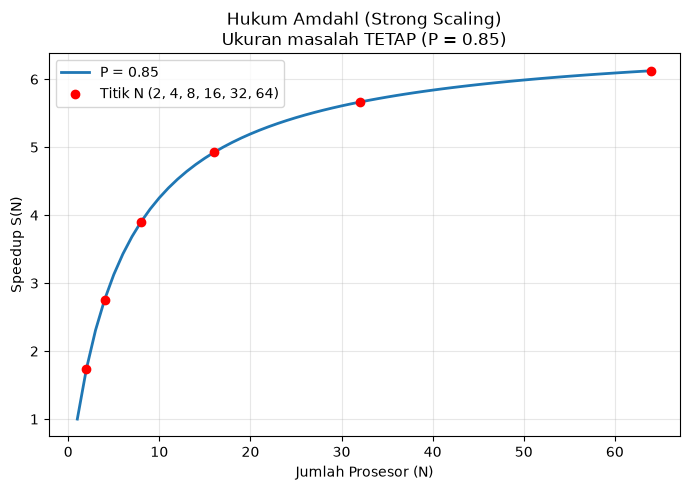

In [2]:
# b) Buat plot speedup vs N 
N_plot = np.arange(1, 65)

plt.figure(figsize=(7, 5))
plt.plot(
    N_plot,
    amdahl_speedup(P, N_plot),
    label=f"P = {P}",
    color="tab:blue",
    linewidth=2,
)

plt.scatter(
    N_values,
    speedups,
    color="red",
    zorder=5,
    label="Titik N (2, 4, 8, 16, 32, 64)",
)

plt.title("Hukum Amdahl (Strong Scaling)\nUkuran masalah TETAP (P = 0.85)")
plt.xlabel("Jumlah Prosesor (N)")
plt.ylabel("Speedup S(N)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**c) Pada $N$ berapa penambahan prosesor mulai memberikan manfaat yang sangat kecil ("diminishing returns")? Jelaskan alasan kalian**   
Berdasarkan hasil perhitungan dan grafik yang diperoleh, efek diminishing returns (penurunan efisiensi tambahan) mulai terasa sangat signifikan saat jumlah prosesor mencapai $N = 16$ hingga $N = 32$. Pada rentang $N = 1$ hingga $N = 16$, peningkatan speedup terjadi cukup pesat dari $1.0\text{x}$ menjadi $4.95\text{x}$. Namun, ketika jumlah prosesor ditambah secara drastis dari $N = 16$ menjadi $N = 64$ (penambahan 48 core), speedup yang diperoleh hanya naik tipis dari $4.95\text{x}$ ke $6.10\text{x}$.Hal ini terjadi karena batas maksimum teoritis (asimtot) speedup untuk nilai $P = 0.85$ adalah $6.67\text{x}$, yang dihitung berdasarkan rumus batas $\frac{1}{1 - P}$. Porsi kode sekuensial sebesar $15\%$ ($1 - P = 0.15$) menjadi batas kritis (bottleneck) utama yang tidak dapat diparalelkan. Oleh karena itu, penambahan prosesor melampaui $16$ core memberikan peningkatan performa yang sangat kecil dan tidak efisien lagi dari segi penggunaan sumber daya hardware.

### 3. Benchmark mandiri: Ambil salah satu fungsi CPU-bound buatan sendiri (boleh modifikasi hitung_prima, atau buat fungsi lain seperti menghitung deret Fibonacci naif secara rekursif). Ukur waktu eksekusinya untuk minimal 4 ukuran input berbeda menggunakan time.perf_counter() dan timeit, lalu bandingkan hasil keduanya dalam satu tabel/plot.

In [3]:
import time
import timeit

def hitung_prima(n):
  count = 0
  for i in range(2, n):
    is_prime = True
    for j in range(2, int(i**0.5) + 1):
      if i % j == 0:
        is_prime = False
        break
    if is_prime:
      count += 1
  return count

input_sizes = [1000, 5000, 10000, 20000]

print(f"{'Ukuran Input (N)':<18} | {'perf_counter() (s)':<20} | {'timeit (s)':<15}")
print("-" * 60)

for size in input_sizes:
  # 1. Menggunakan time.perf_counter()
  t0 = time.perf_counter()
  hitung_prima(size)
  t1 = time.perf_counter()
  waktu_perf = t1 - t0

  # 2. Menggunakan timeit
  waktu_timeit = timeit.timeit(lambda: hitung_prima(size), number=1)

  print(f"{size:<18} | {waktu_perf:<20.6f} | {waktu_timeit:<15.6f}")

Ukuran Input (N)   | perf_counter() (s)   | timeit (s)     
------------------------------------------------------------
1000               | 0.001574             | 0.001067       
5000               | 0.007292             | 0.008234       
10000              | 0.014367             | 0.020526       
20000              | 0.041365             | 0.043483       


### 4. Refleksi singkat (maks. 150 kata): Menurut kalian, kapan Hukum Amdahl lebih relevan digunakan dibanding Hukum Gustafson, dan sebaliknya? Berikan satu contoh kasus nyata untuk masing-masing.
Jawab:     
Hukum Amdahl lebih relevan digunakan pada kondisi strong scaling, yaitu ketika kita ingin menyelesaikan suatu masalah dengan ukuran beban kerja yang tetap (fixed problem size) secara lebih cepat. Contohnya adalah proses rendering video atau gambar 3D dengan resolusi tetap (misalnya 4K), fokus utamanya adalah menambahkan prosesor agar durasi rendering selesai dalam waktu sesingkat mungkin. Sebaliknya, Hukum Gustafson lebih relevan pada kondisi weak scaling, yaitu ketika kita ingin memanfaatkan penambahan prosesor untuk memproses data yang jauh lebih besar dalam alokasi waktu eksekusi yang sama (scalable problem size). Contohnya adalah pelatihan model kecerdasan buatan (AI/Deep Learning) pada dataset raksasa, saat jumlah GPU ditambah, ukuran dataset atau kompleksitas model disesuaikan agar makin besar tanpa memperpanjang total waktu pelatihan.